 15. Outlier Analysis

 16. Correlation Analysis

 17. Findings and Conclusions

### 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from wordcloud import WordCloud, STOPWORDS

### 2. Load Dataset

In [11]:
path = r"../data/raw/training.1600000.processed.noemoticon.csv"

data = pd.read_csv(path, encoding="latin1")

In [12]:
df = pd.DataFrame(data)
df.columns = ["Label", "Serial", "Date", "Query", "Twitter_id", "Tweet"]

### 3. Dataset Overview

In [13]:
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [14]:
df.tail()

,Label,Serial,Date,Query,Twitter_id,Tweet
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599998,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


In [15]:
df.shape

(1599999, 6)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Label       1599999 non-null  int64 
 1   Serial      1599999 non-null  int64 
 2   Date        1599999 non-null  object
 3   Query       1599999 non-null  object
 4   Twitter_id  1599999 non-null  object
 5   Tweet       1599999 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [17]:
df.describe()

,Label,Serial
count,1.599999e+06,1.599999e+06
mean,2.000001e+00,1.998818e+09
std,2.000001e+00,1.935757e+08
min,0.000000e+00,1.467811e+09
25%,0.000000e+00,1.956916e+09
50%,4.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


In [18]:
df.describe(include="all")

,Label,Serial,Date,Query,Twitter_id,Tweet
count,1.599999e+06,1.599999e+06,1599999,1599999,1599999,1599999
unique,NaN,NaN,774362,1,659775,1581465
top,NaN,NaN,Mon Jun 15 12:53:14 PDT 2009,NO_QUERY,lost_dog,isPlayer Has Died! Sorry
freq,NaN,NaN,20,1599999,549,210
mean,2.000001e+00,1.998818e+09,NaN,NaN,NaN,NaN
std,2.000001e+00,1.935757e+08,NaN,NaN,NaN,NaN
min,0.000000e+00,1.467811e+09,NaN,NaN,NaN,NaN
25%,0.000000e+00,1.956916e+09,NaN,NaN,NaN,NaN
50%,4.000000e+00,2.002102e+09,NaN,NaN,NaN,NaN
75%,4.000000e+00,2.177059e+09,NaN,NaN,NaN,NaN


### 4. Missing Values Analysis

In [19]:
df.isnull().sum()

Label         0
Serial        0
Date          0
Query         0
Twitter_id    0
Tweet         0
dtype: int64

In [20]:
df.isna().sum()

Label         0
Serial        0
Date          0
Query         0
Twitter_id    0
Tweet         0
dtype: int64

In [21]:
df["Tweet"].isnull()

0          False
1          False
2          False
3          False
4          False
           ...  
1599994    False
1599995    False
1599996    False
1599997    False
1599998    False
Name: Tweet, Length: 1599999, dtype: bool

In [22]:
df.notnull().sum()

Label         1599999
Serial        1599999
Date          1599999
Query         1599999
Twitter_id    1599999
Tweet         1599999
dtype: int64

In [23]:
df.isnull().sum(axis=1)
# df.isnull().sum(axis="rows")

0          0
1          0
2          0
3          0
4          0
          ..
1599994    0
1599995    0
1599996    0
1599997    0
1599998    0
Length: 1599999, dtype: int64

### 5. Class Distribution

In [24]:
df["Label"].value_counts()

Label
4    800000
0    799999
Name: count, dtype: int64

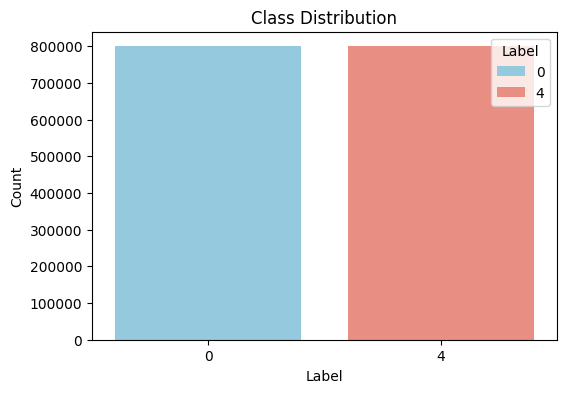

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, hue="Label", palette=["skyblue", "salmon"])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### 6. Convert Labels

In [26]:
df.loc[df["Label"] == 4, "Label"] = 1

In [27]:
df["Label"].value_counts()

Label
1    800000
0    799999
Name: count, dtype: int64

### 7. Sample Tweets

In [28]:
df.loc[df["Label"] == 0, "Tweet"].sample(5)

616718    @Arryvanh ive been putting that off since i mo...
335235    i feel so so so sick!  need cheering up? anyon...
333258                                  Can't fall asleep. 
322816        At the bus stop. I think my legs are burning 
582962    Hey everyone... I'm trying to redo the entire ...
Name: Tweet, dtype: object

In [29]:
df.loc[df["Label"]==1, "Tweet"].sample(5)

1292718    @animalhouse4384 im nb nb  summer strted so im...
1096176    @adrence thank you for the coffee sweety.....I...
1051683    not looking forward to the grocery shopping......
889251     @phpfunk it looks really funny w. the big tv i...
1332268                                    @JGDemas I agree 
Name: Tweet, dtype: object

### 8. Text Length Analysis

In [30]:
df["Length"] = df["Tweet"].str.len()
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29


In [31]:
data = df["Length"]

lenght_mean = np.mean(data)
print(f"{lenght_mean:.2f}")

74.09


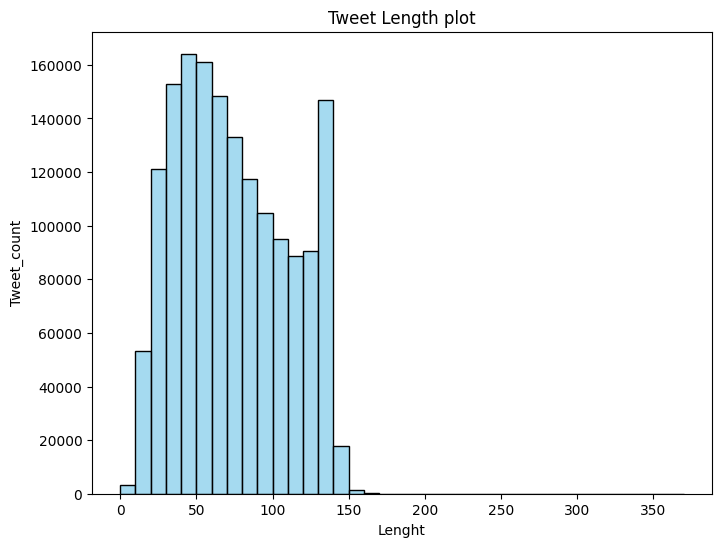

In [32]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df["Length"], color="skyblue", 
             bins=np.arange(0, df["Length"].max(), 10))
plt.title("Tweet Length plot")
plt.xlabel("Lenght")
plt.ylabel("Tweet_count")
plt.show()

In [33]:
max_length = df["Length"].max()
min_lenght = df["Length"].min()

print(f"The longest tweet has {max_length} words.")
print(f"The shortest tweet has {min_lenght} words.")

The longest tweet has 374 words.
The shortest tweet has 6 words.


### 9. Negative/Positive Distribution

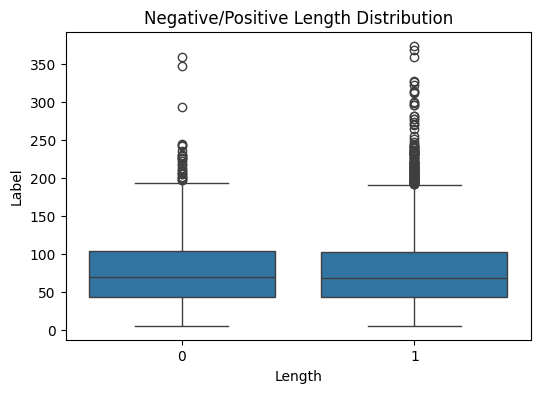

In [34]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Label", y="Length")
plt.title("Negative/Positive Length Distribution")
plt.xlabel("Length")
plt.ylabel("Label")
plt.show()

### 9. URL Analysis

In [35]:
url_pattern = r"https?://\S"

df["Url_Count"] = df["Tweet"].fillna("").str.count(url_pattern)

df["Url_Count"]

0          0
1          0
2          0
3          0
4          0
          ..
1599994    0
1599995    1
1599996    0
1599997    0
1599998    0
Name: Url_Count, Length: 1599999, dtype: int64

In [36]:
print(df["Url_Count"].describe())

count    1.599999e+06
mean     4.471440e-02
std      2.115244e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+00
Name: Url_Count, dtype: float64


In [37]:
url_count = df["Url_Count"].gt(0).sum()
print(f"There are {url_count} Tweets with at least on url.")

There are 70110 Tweets with at least on url.


###  10. Mention Analysis

In [38]:
pattern = r"@\w+"

df["Mentions"] = df["Tweet"].fillna("").str.findall(pattern)

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[]
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan]
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[]
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass]
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei]


In [39]:
df["Mentions_Count"] = df["Mentions"].str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1


In [40]:
mentions_count1 = df["Mentions_Count"].eq(1).sum()
mentions_count2 = df["Mentions_Count"].gt(1).sum()

print(f"There are {mentions_count1} tweets with exacly one mention.")
print(f"There are {mentions_count2} tweets with more than one mention.")

There are 704274 tweets with exacly one mention.
There are 34218 tweets with more than one mention.


In [41]:
negative_mentions_count = ((df["Label"]==0) & (df["Mentions_Count"]>0)).sum()
positive_mentions_count = ((df["Label"]==1) & (df["Mentions_Count"]>0)).sum()

print(f"Ther are {negative_mentions_count} negative tweets with at least one mention.")
print(f"Ther are {positive_mentions_count} positive tweets with at least one mention.")

Ther are 300841 negative tweets with at least one mention.
Ther are 437651 positive tweets with at least one mention.


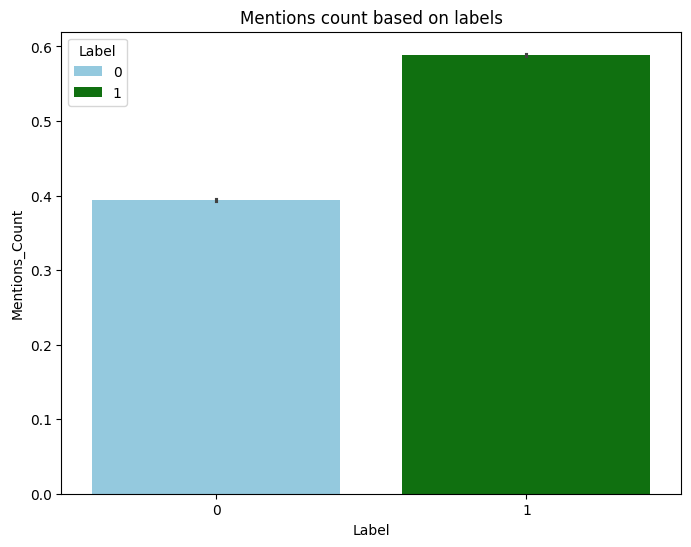

In [42]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Mentions_Count", hue="Label", palette=("skyblue", "green"))
plt.title("Mentions count based on labels")
plt.xlabel("Label")
plt.ylabel("Mentions_Count")
plt.show()

###  11. Hashtag Analysis

In [43]:
hashtag_pattern=r"#\w+"

df["Hashtags"] = df["Tweet"].fillna("").str.findall(hashtag_pattern)

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[]
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[]
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[]
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[]
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[]


In [44]:
df["Hashtags_Count"] = df["Hashtags"].str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0


In [45]:
hashtag_count1 = df["Hashtags_Count"].eq(1).sum()
hashtag_count2 = df["Hashtags_Count"].gt(1).sum()

print(f"There are {hashtag_count1} tweets with exactly one hashtag.")
print(f"There are {hashtag_count2} tweets with more than one hashtag.")

There are 31073 tweets with exactly one hashtag.
There are 4774 tweets with more than one hashtag.


In [46]:
positive_hashtag_count = ((df["Label"] == 1) & (df["Hashtags_Count"] > 0)).sum()
negative_hashtag_count = ((df["Label"] == 0) & (df["Hashtags_Count"] > 0)).sum()

print(f"There are {positive_hashtag_count} positive tweets with at least one hashtag.")
print(f"There are {negative_hashtag_count} negative tweets with at least one hashtag.")

There are 20634 positive tweets with at least one hashtag.
There are 15213 negative tweets with at least one hashtag.


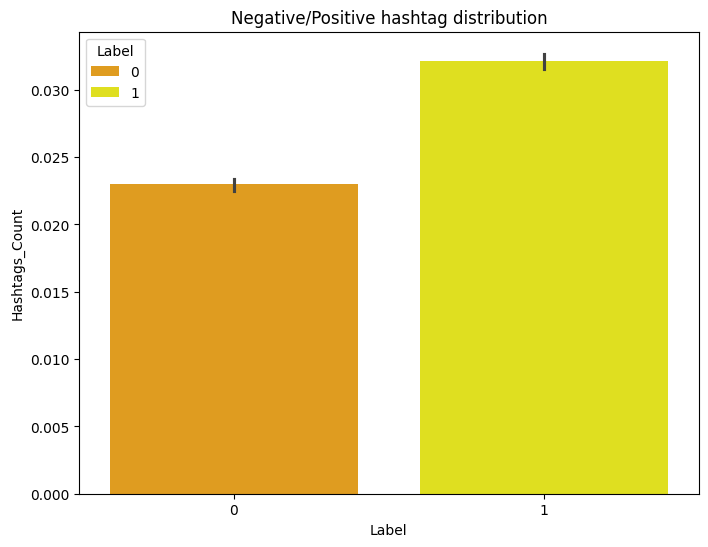

In [47]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Hashtags_Count", hue="Label", palette=("orange", "yellow"))
plt.title("Negative/Positive hashtag distribution")
plt.xlabel("Label")
plt.ylabel("Hashtags_Count")
plt.show()

### 12. Punctuation Marks Analysis

In [48]:
question_pattern = r"\?"

question_marks = df["Tweet"].fillna("").str.findall(question_pattern)

question_marks

0           []
1           []
2           []
3          [?]
4           []
          ... 
1599994     []
1599995     []
1599996    [?]
1599997     []
1599998     []
Name: Tweet, Length: 1599999, dtype: object

In [49]:
df["Question_Count"] = question_marks.str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count,Question_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0,0
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0,0
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0,0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0,1
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0,0


In [50]:
question_count1 = df["Question_Count"].eq(1).sum()
question_count2 = df["Question_Count"].gt(1).sum()

print(f"There are {question_count1} tweets with exactly one ? mark.")
print(f"There are {question_count2} tweets with more than one ? mark.")

There are 129652 tweets with exactly one ? mark.
There are 37656 tweets with more than one ? mark.


In [51]:
positive_questionmark_count = ((df["Label"] == 1) & (df["Question_Count"] > 0)).sum()
negative_question_mark_count = ((df["Label"] == 0) & (df["Question_Count"] > 0)).sum()

print(f"There are {positive_questionmark_count} positive tweets with at least one ? mark.")
print(f"There are {negative_question_mark_count} negative tweets with at least one ? mark.")

There are 86093 positive tweets with at least one ? mark.
There are 81215 negative tweets with at least one ? mark.


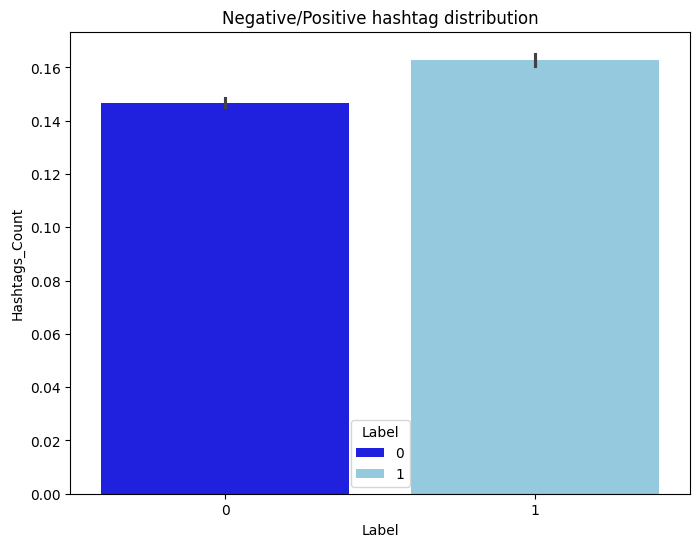

In [52]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Question_Count", hue="Label", palette=("blue", "skyblue"))
plt.title("Negative/Positive hashtag distribution")
plt.xlabel("Label")
plt.ylabel("Hashtags_Count")
plt.show()

In [53]:
exc_pattern = r"!"

exclamation_mark = df["Tweet"].fillna("").str.findall(exc_pattern)

exclamation_mark

0                [!]
1                 []
2                 []
3                 []
4                 []
             ...    
1599994           []
1599995          [!]
1599996           []
1599997    [!, !, !]
1599998           []
Name: Tweet, Length: 1599999, dtype: object

In [54]:
df["Exclamation_Count"] = exclamation_mark.str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count,Question_Count,Exclamation_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0,0,1
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0,0,0
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0,0,0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0,1,0
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0,0,0


In [55]:
exlamation_count1 = df["Exclamation_Count"].eq(0).sum()
exlamation_count2 = df["Exclamation_Count"].gt(1).sum()

print(f"There are {exlamation_count1} tweets with exactly one ! mark.")
print(f"There are {exlamation_count2} tweets with more than one ! mark.")

There are 1118620 tweets with exactly one ! mark.
There are 203239 tweets with more than one ! mark.


In [56]:
positive_exclamationmark_count = ((df["Label"] == 1) & (df["Exclamation_Count"] > 0)).sum()
negative_exclamationmark_count = ((df["Label"] == 0) & (df["Exclamation_Count"] > 0)).sum()

print(f"There are {positive_exclamationmark_count} positive tweets with at least one ! mark.")
print(f"There are {negative_exclamationmark_count} negative tweets with at least one ! mark.")

There are 283031 positive tweets with at least one ! mark.
There are 198348 negative tweets with at least one ! mark.


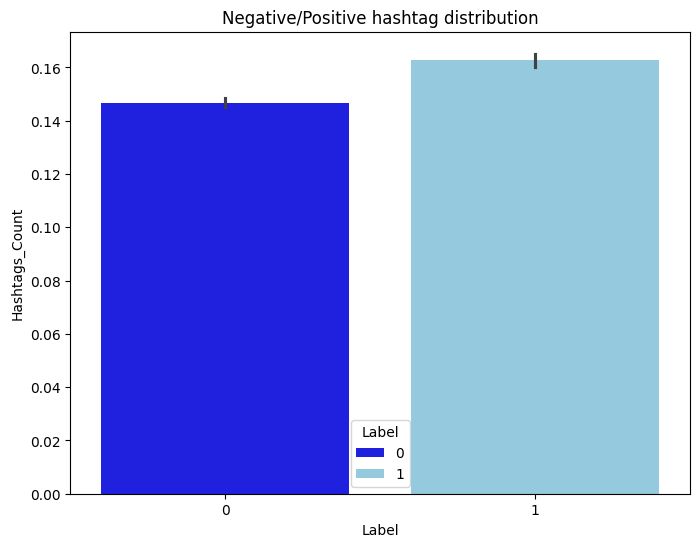

In [57]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Question_Count", hue="Label", palette=("blue", "skyblue"))
plt.title("Negative/Positive hashtag distribution")
plt.xlabel("Label")
plt.ylabel("Hashtags_Count")
plt.show()

### 13. Emoji Analysis

In [58]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    u"\U0001F926-\U0001F937"
    u"\U00010000-\U0010ffff"
    u"\u200d"
    u"\u2640-\u2642"
    u"\u2600-\u2B55"
    u"\u23cf"
    u"\u23e9"
    u"\u231a"
    u"\u3030"
    u"\ufe0f"
    u"\u2069"
    u"\u2066"
    u"\u200c"
    u"\u2068"
    u"\u2067"
    "]+",
    flags=re.UNICODE
)

df["Emojies"] = df["Tweet"].fillna("").str.findall(emoji_pattern)

In [66]:
emoji_count = df["Emojies"].str.len().gt(0).sum()
print(f"There are {emoji_count} emojies in tweets.")

There are 0 emojies in tweets.


### 13. Top Words

In [ ]:
all_tweets = df["Tweet"].fillna("").str.lower()

big_text = " ".join(all_tweets)

words = big_text.split()

top_words = pd.Series(words).value_counts()
top_words

i                            746635
to                           560313
the                          518734
a                            376421
my                           312846
                              ...  
(kidding,                         1
@oxhot                            1
@thrillmesoon                     1
http://tinyurl.com/m6j2an         1
nemuselo                          1
Name: count, Length: 1193583, dtype: int64

In [73]:
top_words[0: 21]

i       746635
to      560313
the     518734
a       376421
my      312846
and     295675
you     237765
is      231086
for     214051
in      209960
it      191053
of      182597
on      161592
so      145770
have    143295
that    128775
me      128490
i'm     127616
but     124676
just    124454
with    113488
Name: count, dtype: int64

###  14. WordCloud

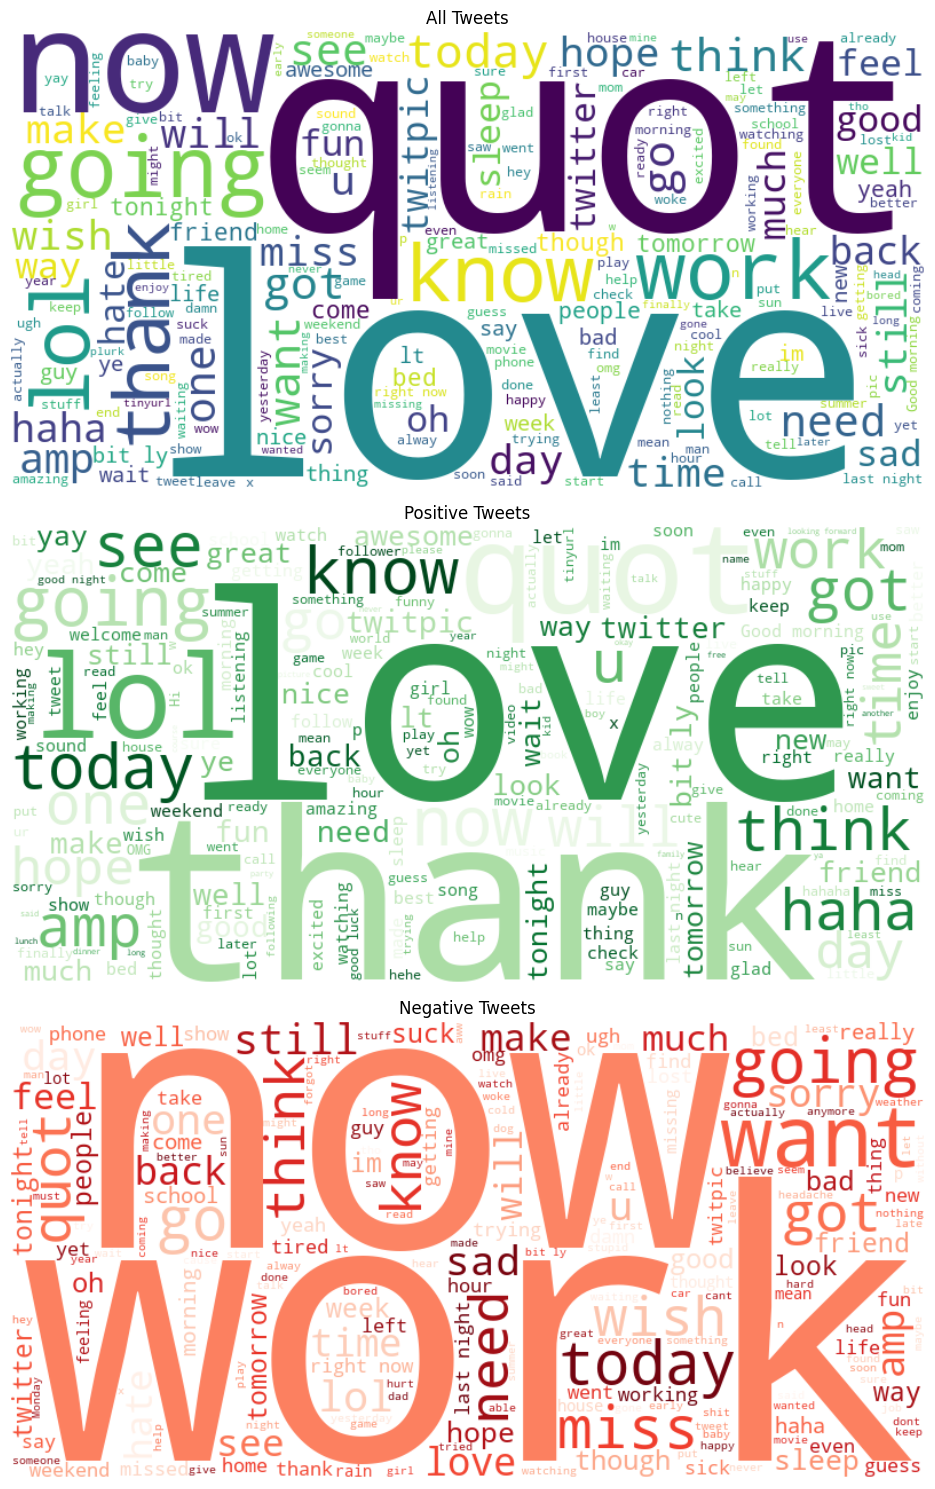

In [65]:
all_text = " ".join(df["Tweet"].fillna("").astype(str))
positive_text = " ".join(df.loc[df["Label"] == 1, "Tweet"].fillna("").astype(str))
negative_text = " ".join(df.loc[df["Label"] == 0, "Tweet"].fillna("").astype(str))

stopwords = set(STOPWORDS)

wc_all = WordCloud(width=800, height=400, background_color="White",
                   stopwords=stopwords).generate(all_text)

wc_positive = WordCloud(width=800, height=400, background_color="White",
                        colormap="Greens", stopwords=stopwords).generate(positive_text)

wc_negative = WordCloud(width=800, height=400, background_color="White",
                   colormap="Reds", stopwords=stopwords).generate(negative_text)


fig, axes = plt.subplots(3, 1, figsize=(12, 15))

axes[0].imshow(wc_all, interpolation="bilinear")
axes[0].set_title("All Tweets")
axes[0].axis("off")


axes[1].imshow(wc_positive, interpolation="bilinear")
axes[1].set_title("Positive Tweets")
axes[1].axis("off")


axes[2].imshow(wc_negative, interpolation="bilinear")
axes[2].set_title("Negative Tweets")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 15. Bigrams and Trigrams